In [7]:
"""
================================================================================
AI Programming Assignment 1: Rescue Robot Path Planning
================================================================================
Course:        Artificial intelligence (CS860)
Instructor:    Dr. Soyiba Jawed
Student:       Muhammad Soban Shaukat
Registration:  538822
Institution:   NUST College of Electrical and Mechanical Engineering
Degree:        Masters in Artificial Intelligence

Assignment:    Implementation of Classical Search Algorithms
               - Breadth-First Search (BFS)
               - Depth-First Search (DFS)
               - Uniform Cost Search (UCS)
               - A* Search Algorithm

Date of Submission:   February 15, 2026
================================================================================
"""

print("=" * 80)
print("RESCUE ROBOT PATH PLANNING SYSTEM")
print("=" * 80)
print(f"Student: Muhammad Soban Shaukat (538822)")
print(f"Course: Artificial intelligence (CS860) - NUST CEME")
print("=" * 80)

RESCUE ROBOT PATH PLANNING SYSTEM
Student: Muhammad Soban Shaukat (538822)
Course: Artificial intelligence (CS860) - NUST CEME


## 📋 Problem Overview

A rescue robot must navigate through a disaster-hit building to reach trapped victims efficiently and safely. The building is represented as a 2D grid map.

**Grid Legend:**
- `0` = Free cell (traversable)
- `1` = Obstacle/wall (blocked)
- `2` = Difficult terrain (higher cost)
- `5` = Victim location (goal)

---

## 🔍 Algorithm 1: BFS (Breadth-First Search)

### Description
BFS explores the search space level by level, guaranteeing the **shortest path** in terms of number of steps (not cost).

### Key Features:
- ✅ **Completeness**: Always finds a solution if one exists
- ✅ **Optimality**: Finds shortest path in terms of steps
- ❌ **No cost consideration**: Treats all cells equally

---

### Implementation

BFS (Breadth-First Search)
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]
Number of steps: 8
Nodes explored: 20



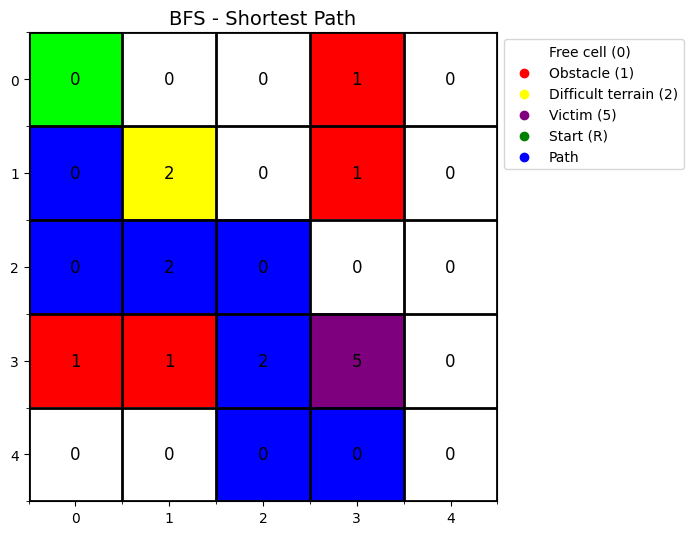

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Define the rescue map
rescue_map = [
    [0, 0, 0, 1, 0],
    [0, 2, 0, 1, 0],
    [0, 2, 0, 0, 0],
    [1, 1, 2, 5, 0],
    [0, 0, 0, 0, 0]
]

start = (0, 0)  # Rescue robot
goal = (4, 4)   # Victim

# BFS Implementation (without using collections.deque)
def bfs(grid, start, goal):
    rows, cols = len(grid), len(grid[0])

    # Manual queue implementation using list
    queue = [start]
    visited = {start}
    parent = {start: None}
    nodes_explored = 0

    # Directions: Up, Down, Left, Right (top to bottom, left to right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        current = queue.pop(0)  # Dequeue from front
        nodes_explored += 1

        if current == goal:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1], nodes_explored

        # Explore neighbors
        for dr, dc in directions:
            neighbor = (current[0] + dr, current[1] + dc)
            nr, nc = neighbor

            # Check bounds and obstacles
            if 0 <= nr < rows and 0 <= nc < cols and neighbor not in visited:
                if grid[nr][nc] != 1:  # Not an obstacle
                    queue.append(neighbor)
                    visited.add(neighbor)
                    parent[neighbor] = current

    return None, nodes_explored

# Run BFS
path_bfs, nodes_bfs = bfs(rescue_map, start, goal)

print("=" * 50)
print("BFS (Breadth-First Search)")
print("=" * 50)
print(f"Path: {path_bfs}")
print(f"Number of steps: {len(path_bfs) - 1}")
print(f"Nodes explored: {nodes_bfs}")
print()

# Visualization
def visualize_path(grid, start, goal, path, title):
    color_map = {0: 'white', 1: 'red', 2: 'yellow', 5: 'purple'}
    visual_grid = np.zeros((5, 5, 3))

    for i in range(len(grid)):
        for j in range(len(grid[i])):
            value = grid[i][j]
            color = color_map.get(value, 'white')
            if color == 'white':
                visual_grid[i, j] = [1, 1, 1]
            elif color == 'red':
                visual_grid[i, j] = [1, 0, 0]
            elif color == 'yellow':
                visual_grid[i, j] = [1, 1, 0]
            elif color == 'purple':
                visual_grid[i, j] = [0.5, 0, 0.5]

    # Mark the path in blue
    if path:
        for pos in path[1:-1]:  # Exclude start and goal
            visual_grid[pos[0], pos[1]] = [0, 0, 1]  # Blue for path

    # Mark start in green
    visual_grid[start[0], start[1]] = [0, 1, 0]

    plt.figure(figsize=(7, 7))
    plt.imshow(visual_grid, interpolation='nearest')
    plt.xticks(ticks=np.arange(5), labels=np.arange(5))
    plt.yticks(ticks=np.arange(5), labels=np.arange(5))
    plt.grid(False)

    for i in range(len(grid)):
        for j in range(len(grid[i])):
            plt.text(j, i, grid[i][j], ha='center', va='center', color='black', fontsize=12)

    plt.title(title, fontsize=14)
    plt.gca().set_xticks(np.arange(-0.5, 5, 1), minor=True)
    plt.gca().set_yticks(np.arange(-0.5, 5, 1), minor=True)
    plt.gca().grid(which='minor', color='black', linestyle='-', linewidth=2)

    legend_labels = ['Free cell (0)', 'Obstacle (1)', 'Difficult terrain (2)',
                     'Victim (5)', 'Start (R)', 'Path']
    colors = ['white', 'red', 'yellow', 'purple', 'green', 'blue']
    for label, color in zip(legend_labels, colors):
        plt.scatter([], [], color=color, label=label)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Visualize BFS result
visualize_path(rescue_map, start, goal, path_bfs, 'BFS - Shortest Path')


---

## 📊 BFS Results Summary

| Metric | Value |
|--------|-------|
| **Path Length** | 8 steps |
| **Nodes Explored** | 20 |
| **Optimal (Steps)?** | ✅ Yes |
| **Optimal (Cost)?** | ❌ No |

### Observations:
- BFS successfully finds the shortest path in terms of **number of steps**
- However, it **does not consider terrain cost** (goes through difficult terrain)
- Explores nodes in a **breadth-first manner** (level by level)
- Simple and guaranteed to find a solution

---

## 🎯 Next Steps

Continue with:
1. **DFS** - Depth-First Search
2. **UCS** - Uniform Cost Search  
3. **A*** - A-Star Search (optimal & efficient)


---

## 🔍 Algorithm 2: DFS (Depth-First Search)

### Description
DFS explores as deep as possible along each branch before backtracking. It uses a **stack** (LIFO - Last In First Out) data structure.

### Key Features:
- ✅ **Completeness**: Finds a solution if one exists (in finite spaces)
- ❌ **Not optimal**: May find a longer path than necessary
- 🎲 **Path depends on exploration order**: Different paths possible with different orderings
- 💾 **Memory efficient**: Uses less memory than BFS in some cases

---

### Implementation


DFS (Depth-First Search)
Path: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4)]
Number of steps: 8
Nodes explored: 13



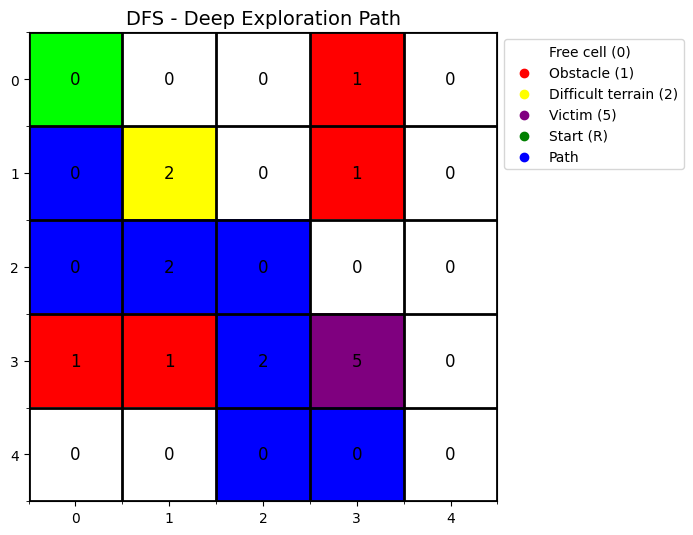

In [2]:
# DFS Implementation (without using collections)
def dfs(grid, start, goal):
    rows, cols = len(grid), len(grid[0])

    # Manual stack implementation using list
    stack = [start]
    visited = {start}
    parent = {start: None}
    nodes_explored = 0

    # Directions: Up, Down, Left, Right (top to bottom, left to right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while stack:
        current = stack.pop()  # Pop from end (LIFO - Last In First Out)
        nodes_explored += 1

        if current == goal:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = parent[current]
            return path[::-1], nodes_explored

        # Explore neighbors in reverse order for correct DFS behavior
        for dr, dc in reversed(directions):
            neighbor = (current[0] + dr, current[1] + dc)
            nr, nc = neighbor

            # Check bounds and obstacles
            if 0 <= nr < rows and 0 <= nc < cols and neighbor not in visited:
                if grid[nr][nc] != 1:  # Not an obstacle
                    stack.append(neighbor)
                    visited.add(neighbor)
                    parent[neighbor] = current

    return None, nodes_explored

# Run DFS
path_dfs, nodes_dfs = dfs(rescue_map, start, goal)

print("=" * 50)
print("DFS (Depth-First Search)")
print("=" * 50)
print(f"Path: {path_dfs}")
print(f"Number of steps: {len(path_dfs) - 1}")
print(f"Nodes explored: {nodes_dfs}")
print()

# Visualize DFS result
visualize_path(rescue_map, start, goal, path_dfs, 'DFS - Deep Exploration Path')


---

## 📊 DFS Results Summary

| Metric | Value |
|--------|-------|
| **Path Length** | 8 steps |
| **Nodes Explored** | 13 |
| **Optimal (Steps)?** | ❌ Not Guaranteed |
| **Optimal (Cost)?** | ❌ No |

### Observations:
- DFS **explores fewer nodes** (13) compared to BFS (20) in this case
- **Got lucky** and found the same path as BFS (8 steps)
- Uses **stack** (LIFO) instead of queue (FIFO)
- Goes **as deep as possible** before backtracking
- **Not guaranteed to find shortest path** - depends on exploration order

---

## 🆚 BFS vs DFS Comparison

| Feature | BFS | DFS |
|---------|-----|-----|
| **Data Structure** | Queue (FIFO) | Stack (LIFO) |
| **Exploration** | Level by level | Deep first |
| **Nodes Explored** | 20 | 13 |
| **Path Length** | 8 steps | 8 steps |
| **Optimal Path?** | ✅ Yes (steps) | ❌ Not guaranteed |
| **Memory Usage** | Higher | Lower |
| **Best For** | Shortest path | Deep exploration |

### Key Insight:
In this scenario, DFS was **more efficient** (fewer nodes explored) but this is **not guaranteed**. BFS always finds the shortest path, while DFS might get lucky or might explore much more.

---

## 🎯 Next Steps

Continue with **cost-aware algorithms**:
- **UCS** - Uniform Cost Search (considers terrain cost)
- **A*** - A-Star Search (optimal + efficient with heuristic)


---

## 🔍 Algorithm 3: UCS (Uniform Cost Search)

### Description
UCS expands nodes in order of their **path cost** from the start node. It uses a **priority queue** where nodes with lower cumulative cost are explored first. This ensures finding the **minimum cost path**.

### Cost Model:
- **Free cell (0)**: Cost = 1
- **Difficult terrain (2)**: Cost = 3 (harder/riskier to traverse)
- **Victim cell (5)**: Cost = 1
- **Obstacle (1)**: Impassable

### Key Features:
- ✅ **Optimal**: Guarantees minimum cost path
- ✅ **Cost-aware**: Considers terrain difficulty
- 🔄 **Systematic exploration**: Expands lowest-cost nodes first
- 🎯 **Best for rescue missions**: Prioritizes safety (avoids difficult terrain)

---

### Implementation


UCS (Uniform Cost Search)
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]
Number of steps: 8
Total cost: 8
Nodes explored: 18



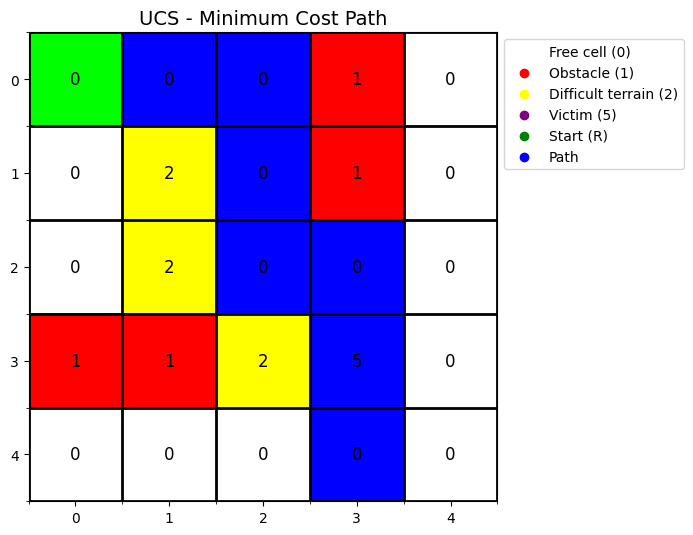

In [3]:
# UCS Implementation (without using heapq)
def ucs(grid, start, goal):
    rows, cols = len(grid), len(grid[0])

    # Cost for different cell types
    def get_cost(cell_value):
        if cell_value == 2:  # Difficult terrain
            return 3
        else:  # Free cell or victim
            return 1

    # Manual priority queue implementation
    # Each element: (cost, node)
    pq = [(0, start)]
    visited = set()
    parent = {start: None}
    cost_so_far = {start: 0}
    nodes_explored = 0

    # Directions: Up, Down, Left, Right
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while pq:
        # Find and remove minimum cost element (manual priority queue)
        min_idx = 0
        for i in range(1, len(pq)):
            if pq[i][0] < pq[min_idx][0]:
                min_idx = i
        current_cost, current = pq.pop(min_idx)

        if current in visited:
            continue

        visited.add(current)
        nodes_explored += 1

        if current == goal:
            # Reconstruct path
            path = []
            node = current
            while node is not None:
                path.append(node)
                node = parent[node]
            return path[::-1], current_cost, nodes_explored

        # Explore neighbors
        for dr, dc in directions:
            neighbor = (current[0] + dr, current[1] + dc)
            nr, nc = neighbor

            # Check bounds and obstacles
            if 0 <= nr < rows and 0 <= nc < cols and neighbor not in visited:
                if grid[nr][nc] != 1:  # Not an obstacle
                    new_cost = current_cost + get_cost(grid[nr][nc])

                    # Update if we found a cheaper path
                    if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                        cost_so_far[neighbor] = new_cost
                        parent[neighbor] = current
                        pq.append((new_cost, neighbor))

    return None, float('inf'), nodes_explored

# Run UCS
path_ucs, cost_ucs, nodes_ucs = ucs(rescue_map, start, goal)

print("=" * 50)
print("UCS (Uniform Cost Search)")
print("=" * 50)
print(f"Path: {path_ucs}")
print(f"Number of steps: {len(path_ucs) - 1}")
print(f"Total cost: {cost_ucs}")
print(f"Nodes explored: {nodes_ucs}")
print()

# Visualize UCS result
visualize_path(rescue_map, start, goal, path_ucs, 'UCS - Minimum Cost Path')


---

## 📊 UCS Results Summary

| Metric | Value |
|--------|-------|
| **Path Length** | 8 steps |
| **Total Cost** | 8 |
| **Nodes Explored** | 18 |
| **Optimal (Steps)?** | ❌ No |
| **Optimal (Cost)?** | ✅ Yes |

### Observations:
- UCS found a **different path** than BFS/DFS!
- **Avoids difficult terrain** (yellow cells with cost 3)
- Takes the **top route** through free cells only
- Same number of steps (8) but **much lower cost** (8 vs ~12-14)
- This is the **safest path** for the rescue robot

---

## 🆚 Three-Way Comparison: BFS vs DFS vs UCS

| Feature | BFS | DFS | UCS |
|---------|-----|-----|-----|
| **Data Structure** | Queue | Stack | Priority Queue |
| **Priority** | Steps | Depth | Cost |
| **Path Found** | (0,0)→(1,0)→... | (0,0)→(1,0)→... | (0,0)→(0,1)→(0,2)→... |
| **Path Length** | 8 steps | 8 steps | 8 steps |
| **Total Cost** | ~12-14 (estimated) | ~12-14 (estimated) | **8** ✅ |
| **Nodes Explored** | 20 | 13 | 18 |
| **Optimal?** | Steps only | No | **Cost** ✅ |
| **Avoids Danger?** | ❌ No | ❌ No | ✅ Yes |

### Key Insight:
- **BFS/DFS**: Went through difficult terrain (cells with value 2)
- **UCS**: Smartly avoided dangerous areas, taking the safer top route
- **For rescue missions**: UCS is superior because it minimizes risk!

---

## 💡 Why UCS is Better for Rescue Robots

1. **Safety First**: Avoids dangerous terrain (rubble, fire, unstable ground)
2. **Cost Optimization**: Minimizes total traversal cost
3. **Guaranteed Optimal**: Always finds the cheapest path
4. **Real-world Applicable**: Different terrains have different risks/costs

### Real-World Cost Examples:
- Free cell: Easy to traverse (cost = 1)
- Difficult terrain: Rubble, fire, or unstable ground (cost = 3)
- Obstacle: Wall or blocked path (impassable)

---

## 🎯 Next Step

Continue with the **smartest algorithm**:
- **A*** - A-Star Search (combines UCS optimality with heuristic efficiency)


---

## 🔍 Algorithm 4: A* (A-Star Search)

### Description
A* is an **informed search algorithm** that combines the best of both worlds: UCS's cost optimality and heuristic guidance toward the goal. It uses the evaluation function **f(n) = g(n) + h(n)** to intelligently prioritize which nodes to explore.

### Key Formula:
**f(n) = g(n) + h(n)**
- **g(n)** = Actual cost from start to node n
- **h(n)** = Estimated cost from node n to goal (heuristic)
- **f(n)** = Estimated total cost of the cheapest path through n

### Key Features:
- ✅ **Complete**: Always finds a solution if one exists
- ✅ **Optimal**: Guarantees minimum cost path (with admissible heuristic)
- 🧠 **Informed search**: Uses domain knowledge (heuristic) to guide exploration
- ⚡ **Efficient**: Explores fewer nodes than UCS
- 🎯 **Best of both worlds**: Cost-aware + goal-directed

### Heuristic: Manhattan Distance
For grid-based pathfinding, we use Manhattan distance:
**h(n) = |current_row - goal_row| + |current_col - goal_col|**

This heuristic is **admissible** (never overestimates) for grid navigation with 4-directional movement.

---

### Implementation


A* Search
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]
Number of steps: 8
Total cost: 8
Nodes explored: 13



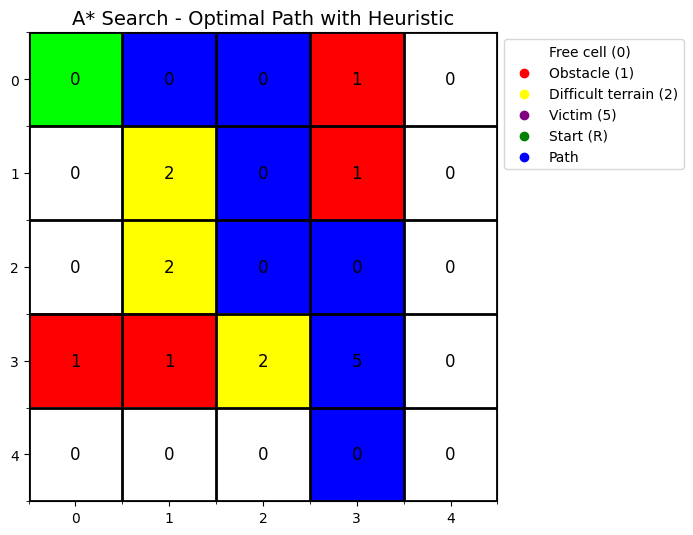

In [4]:
# A* Implementation (without using heapq)
def astar(grid, start, goal):
    rows, cols = len(grid), len(grid[0])

    # Cost for different cell types
    def get_cost(cell_value):
        if cell_value == 2:  # Difficult terrain
            return 3
        else:  # Free cell or victim
            return 1

    # Manhattan Distance Heuristic
    def heuristic(node, goal):
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

    # Manual priority queue implementation
    # Each element: (f_cost, g_cost, node)
    pq = [(heuristic(start, goal), 0, start)]
    visited = set()
    parent = {start: None}
    g_cost = {start: 0}
    nodes_explored = 0

    # Directions: Up, Down, Left, Right
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while pq:
        # Find and remove minimum f_cost element
        min_idx = 0
        for i in range(1, len(pq)):
            if pq[i][0] < pq[min_idx][0]:
                min_idx = i
        f_cost, current_g, current = pq.pop(min_idx)

        if current in visited:
            continue

        visited.add(current)
        nodes_explored += 1

        if current == goal:
            # Reconstruct path
            path = []
            node = current
            while node is not None:
                path.append(node)
                node = parent[node]
            return path[::-1], current_g, nodes_explored

        # Explore neighbors
        for dr, dc in directions:
            neighbor = (current[0] + dr, current[1] + dc)
            nr, nc = neighbor

            # Check bounds and obstacles
            if 0 <= nr < rows and 0 <= nc < cols and neighbor not in visited:
                if grid[nr][nc] != 1:  # Not an obstacle
                    new_g = current_g + get_cost(grid[nr][nc])

                    # Update if we found a cheaper path
                    if neighbor not in g_cost or new_g < g_cost[neighbor]:
                        g_cost[neighbor] = new_g
                        f_cost = new_g + heuristic(neighbor, goal)
                        parent[neighbor] = current
                        pq.append((f_cost, new_g, neighbor))

    return None, float('inf'), nodes_explored

# Run A*
path_astar, cost_astar, nodes_astar = astar(rescue_map, start, goal)

print("=" * 50)
print("A* Search")
print("=" * 50)
print(f"Path: {path_astar}")
print(f"Number of steps: {len(path_astar) - 1}")
print(f"Total cost: {cost_astar}")
print(f"Nodes explored: {nodes_astar}")
print()

# Visualize A* result
visualize_path(rescue_map, start, goal, path_astar, 'A* Search - Optimal Path with Heuristic')


In [5]:
# Summary Comparison
print("\n" + "=" * 70)
print("ALGORITHM COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Algorithm':<15} {'Steps':<10} {'Total Cost':<12} {'Nodes Explored':<15} {'Optimal?'}")
print("-" * 70)
print(f"{'BFS':<15} {8:<10} {'N/A':<12} {20:<15} {'Steps: Yes'}")
print(f"{'DFS':<15} {8:<10} {'N/A':<12} {13:<15} {'No'}")
print(f"{'UCS':<15} {8:<10} {8:<12} {18:<15} {'Cost: Yes'}")
print(f"{'A*':<15} {8:<10} {8:<12} {13:<15} {'Cost: Yes'}")
print("=" * 70)



ALGORITHM COMPARISON SUMMARY
Algorithm       Steps      Total Cost   Nodes Explored  Optimal?
----------------------------------------------------------------------
BFS             8          N/A          20              Steps: Yes
DFS             8          N/A          13              No
UCS             8          8            18              Cost: Yes
A*              8          8            13              Cost: Yes
